## Transverse field Ising model to demo primitives

In [1]:
from qiskit import QuantumCircuit
from qiskit.circuit.library import YGate, UnitaryGate
import numpy as np

SYGate = UnitaryGate(YGate().power(1/2),label=r"$\sqrt{Y}$")
SYdgGate = UnitaryGate(SYGate.inverse(), label=r"$\sqrt{Y}^\dag$")

def generate_1d_tfim_circuit(num_qubits, num_trotter_steps, rx_angle, num_cl_bits = 0, trotter_barriers = False, layer_barriers = False):
    if num_cl_bits == 0:
        qc = QuantumCircuit(num_qubits)
    else:
        qc = QuantumCircuit(num_qubits, num_cl_bits)

    for trotter_step in range(num_trotter_steps):
        add_1d_tfim_layer(qc, rx_angle,layer_barriers)
        if trotter_barriers:
            qc.barrier()

    return qc

def add_1d_tfim_layer(qc, rx_angle, layer_barriers = False):
    # Adding Rzz in even layers
    for i in range(0,qc.num_qubits -1, 2):
        qc.sdg([i, i+1])
        qc.append(SYGate, [i+1])
        qc.cx(i, i+1)
        qc.append(SYdgGate, [i+1])
    if layer_barriers:
        qc.barrier()
    # Adding Rzz in the odd layers
    for i in range(1,qc.num_qubits -1, 2):
        qc.sdg([i, i+1])
        qc.append(SYGate, [i+1])
        qc.cx(i, i+1)
        qc.append(SYdgGate, [i+1])
    if layer_barriers:
        qc.barrier()
    qc.rx(rx_angle, list(range(qc.num_qubits)))
    if layer_barriers:
        qc.barrier()



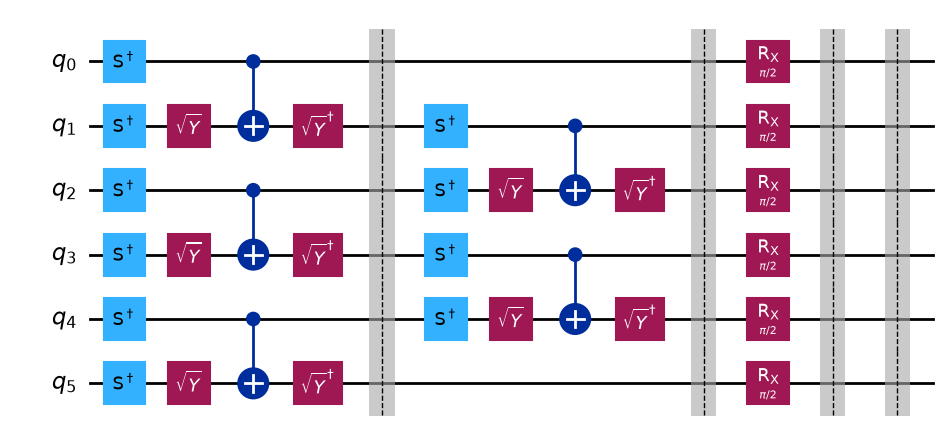

In [2]:
num_qubits = 6
num_trotter_steps = 1
rx_angle = 0.5 * np.pi

qc = generate_1d_tfim_circuit(num_qubits, num_trotter_steps, rx_angle, trotter_barriers = True, layer_barriers = True)
qc.draw(output='mpl', fold=-1)

## Demo: Sampler

In [3]:
def append_mirrored_1d_tfim_circuit(qc,num_qubits, num_trotter_steps, rx_angle, trotter_barriers = True, layer_barriers = True):
    for trotter_step in range(num_trotter_steps):
        add_mirrored_1d_tfim_trotter_layer(qc, rx_angle, layer_barriers)
        if trotter_barriers:
            qc.barrier()

def add_mirrored_1d_tfim_trotter_layer(qc, rx_angle, layer_barriers = False):
    qc.rx(-rx_angle, list(range(qc.num_qubits)))
    if layer_barriers:
        qc.barrier()
    # Ading Rzz in the odd layer
    for i in range(1, qc.num_qubits - 1, 2):
        qc.append(SYGate,[i+1])
        qc.cx(i,i+1)
        qc.append(SYdgGate,[i+1])
        qc.s([i,i+1])
    if layer_barriers:
        qc.barrier()
    # Ading Rzz in the even layer
    for i in range(0, qc.num_qubits - 1, 2):
        qc.append(SYGate,[i+1])
        qc.cx(i,i+1)
        qc.append(SYdgGate,[i+1])
        qc.s([i,i+1])
    if layer_barriers:
        qc.barrier()

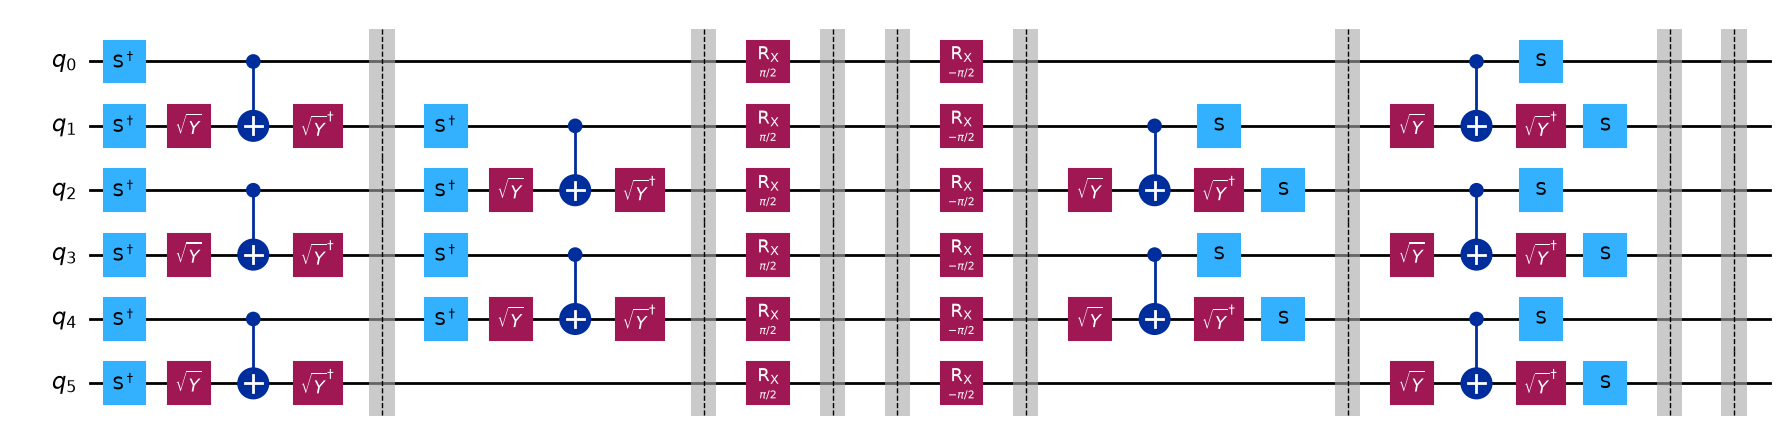

In [4]:
append_mirrored_1d_tfim_circuit(qc, num_qubits, num_trotter_steps, rx_angle, trotter_barriers = True, layer_barriers = True)
qc.draw(output='mpl',fold=-1)

## Step 1: Map the problem to circuits and observables

In [5]:
max_trotter_steps = 10
num_qubits = 100
measured_qubits = [49,50]

qc_list = []
for trotter_steps in range(max_trotter_steps):
    qc = generate_1d_tfim_circuit(num_qubits, trotter_steps, rx_angle, num_cl_bits=len(measured_qubits),trotter_barriers=True, layer_barriers=True)
    append_mirrored_1d_tfim_circuit(qc, num_qubits, trotter_steps, rx_angle, trotter_barriers = True, layer_barriers = True)
    qc.measure(measured_qubits, list(range(len(measured_qubits))))
    qc_list.append(qc)

## Step 2: Optimize

In [6]:
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

service = QiskitRuntimeService()
backend = service.backend("ibm_kingston")
print("Done getting the backend.")
pass_manager = generate_preset_pass_manager(optimization_level=1, backend=backend)

qc_transpiled_list = pass_manager.run(qc_list)

Done getting the backend.


## Step 3: Execute on hardware

In [7]:
from qiskit_ibm_runtime import SamplerV2 as Sampler

sampler = Sampler(backend)
sampler.options.dynamical_decoupling.enable = True
sampler.options.dynamical_decoupling.sequence_type = 'XY4'

#job = sampler.run(qc_transpiled_list)
#print(job.job_id())

## Step 4: Post-processing and plotting

In [8]:
job_id = "d98rkvkqp3as739tantg"
job = service.job(job_id)

survival_probability_list = []
for trotter_steps in range(max_trotter_steps):
    try:
        data = job.result()[trotter_steps].data
        survival_probability_list.append(data.c.get_counts()['0'*len(measured_qubits)] / data.c.num_shots)
    except:
        survival_probability_list.append(0)

([<matplotlib.axis.XTick at 0x79496aca3750>,
 [Text(0, 0, '0'),
  Text(4, 0, '4'),
  Text(8, 0, '8'),
  Text(12, 0, '12'),
  Text(16, 0, '16'),
  Text(20, 0, '20'),
  Text(24, 0, '24'),
  Text(28, 0, '28'),
  Text(32, 0, '32'),
  Text(36, 0, '36'),
  Text(40, 0, '40')])

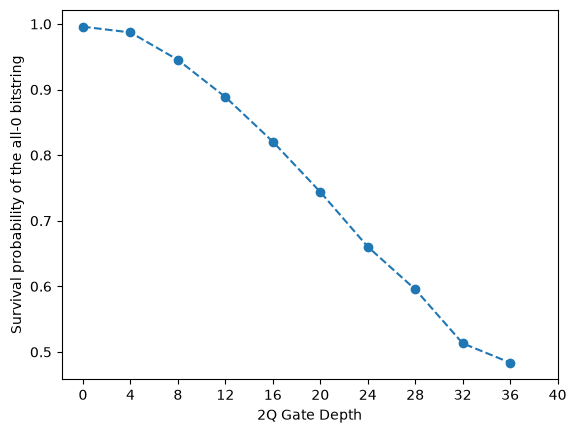

In [9]:
import matplotlib.pyplot as plt

plt.plot(list(range(0,4*max_trotter_steps,4)), survival_probability_list,'--o')
plt.xlabel('2Q Gate Depth')
plt.ylabel('Survival probability of the all-0 bitstring')
plt.xticks(np.arange(0,44,4))

## Demo: Estimator

## Step 1: Mapping the problem

In [10]:
from qiskit.circuit import Parameter

rx_angle = Parameter("rx_angle")
trotter_steps = 2
qc = generate_1d_tfim_circuit(num_qubits,trotter_steps,rx_angle)

from qiskit.quantum_info import SparsePauliOp
middle_idx = num_qubits//2
observable = SparsePauliOp("I"*middle_idx + "Z" + "I"*(middle_idx-1))

## Step 2: Optimize the circuit

In [11]:
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService

service = QiskitRuntimeService()
backend = service.backend(name='ibm_kingston')
pass_manager = generate_preset_pass_manager(optimization_level=1, backend=backend)
qc_transpiled = pass_manager.run(qc)
observable = observable.apply_layout(qc_transpiled.layout)

## Step 3: Execute on quantum hardware

In [12]:
from qiskit_ibm_runtime import EstimatorV2, EstimatorOptions

min_rx_angle = 0
max_rx_angle = np.pi/2
num_rx_angle = 12
rx_angle_list = np.linspace(min_rx_angle, max_rx_angle, num_rx_angle)

options = EstimatorOptions()
options.resilience_level = 1
options.dynamical_decoupling.enable = True
options.dynamical_decoupling.sequence_type = "XY4"

estimator = EstimatorV2(backend, options=options)

#job = estimator.run([(qc_transpiled,observable,rx_angle_list)])
#print(job.job_id())

## Step 4: Post-processing and plotting

(-0.1, 1.1)

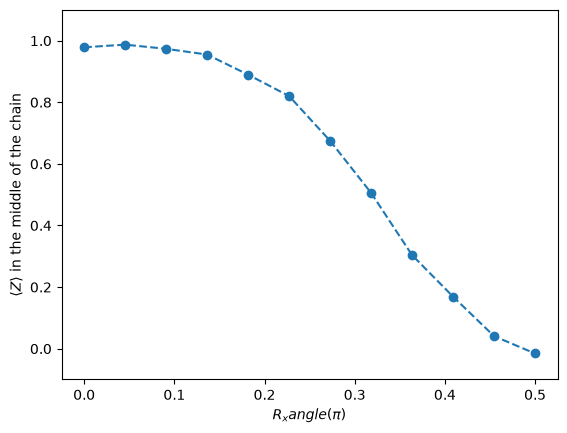

In [13]:
job_id = 'd9a8kvcqp3as739v00v0'
job = service.job(job_id)

exp_val_list = job.result()[0].data.evs

plt.plot(rx_angle_list / np.pi, exp_val_list, '--o')
plt.xlabel(r' $R_x angle (\pi)$ ')
plt.ylabel(r'$ \langle Z \rangle $ in the middle of the chain')
plt.ylim(-0.1,1.1)